# 07 Deep Learning — Model Training

⚠️ **IMPORTANT: DO NOT RE-RUN THIS NOTEBOOK ACCIDENTALLY**

This notebook trains two computationally expensive DL models.  
**Only run if you intentionally need to retrain.**

---

## Purpose

Train two deep learning architectures on preprocessed text from notebook 06:

| Model | Architecture | Key DL Techniques |
|-------|-------------|-------------------|
| **BiLSTM + Attention** | Embedding → 2-layer BiLSTM → Self-Attention → FC | Orthogonal init, forget-gate bias, gradient clipping |
| **DistilBERT** | Pretrained Transformer → LayerNorm → FC | Differential LR, selective layer freezing, transfer learning |

### Prerequisites
Run `06_dl_data_preprocessing.ipynb` first to generate the preprocessed tensors in `results/`.

## 1. Imports and Load Preprocessed Data

In [10]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_ROOT = Path('.').resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.deep_learning import (
    LSTMConfig, TransformerConfig, TrainingConfig,
    TextClassificationDataset, TransformerDataset,
    BiLSTMClassifier, DistilBERTClassifier,
    train_lstm_model, train_transformer_model,
    get_device,
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = PROJECT_ROOT / 'figures'
METRICS_DIR = PROJECT_ROOT / 'metrics'
for d in [RESULTS_DIR, FIGURES_DIR, METRICS_DIR]:
    d.mkdir(exist_ok=True)

device = get_device()
print(f'PyTorch {torch.__version__} | Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print('GPU: Apple Silicon (MPS)')

PyTorch 2.11.0 | Device: mps
GPU: Apple Silicon (MPS)


In [11]:
# Load preprocessed artifacts from notebook 06
train_ids = torch.load(RESULTS_DIR / 'dl_train_ids.pt', weights_only=True)
val_ids   = torch.load(RESULTS_DIR / 'dl_val_ids.pt',   weights_only=True)
test_ids  = torch.load(RESULTS_DIR / 'dl_test_ids.pt',  weights_only=True)

y_train = np.load(RESULTS_DIR / 'dl_y_train.npy')
y_val   = np.load(RESULTS_DIR / 'dl_y_val.npy')
y_test  = np.load(RESULTS_DIR / 'dl_y_test.npy')

with open(RESULTS_DIR / 'dl_tokenizer.json') as f:
    tok_data = json.load(f)
vocab_size = len(tok_data['word2idx'])

print(f'Loaded word-level tensors:')
print(f'  Train: {train_ids.shape}  Val: {val_ids.shape}  Test: {test_ids.shape}')
print(f'  Vocab size: {vocab_size:,}')
print(f'  Labels — Train: {len(y_train):,}  Val: {len(y_val):,}  Test: {len(y_test):,}')

Loaded word-level tensors:
  Train: torch.Size([72000, 491])  Val: torch.Size([8000, 488])  Test: torch.Size([20000, 475])
  Vocab size: 28,903
  Labels — Train: 72,000  Val: 8,000  Test: 20,000


## 2. Model A — BiLSTM + Self-Attention

### Architecture (not a black box)

```
Input tokens  (batch, seq_len)
       │
       ▼
┌──────────────────┐
│  Embedding Layer │  Xavier uniform init, dim=128
│  + Dropout(0.3)  │  Padding idx kept at zero vector
└────────┬─────────┘
         ▼
┌──────────────────┐
│  2-layer BiLSTM  │  hidden=256, orthogonal recurrent init
│  (512-d output)  │  Forget-gate bias = 1 (long-range memory)
└────────┬─────────┘
         ▼
┌──────────────────┐
│  Self-Attention   │  Learned query vector scores each timestep;
│  Pooling          │  softmax → weighted sum → fixed-length context
└────────┬─────────┘
         ▼
┌──────────────────┐
│  LayerNorm        │  Stabilises distribution of context vector
│  + Dropout(0.3)  │
└────────┬─────────┘
         ▼
┌──────────────────┐
│  FC 512 → 256    │  Kaiming (He) init, ReLU activation
│  + Dropout(0.3)  │
└────────┬─────────┘
         ▼
┌──────────────────┐
│  FC 256 → 2      │  Output logits (Won / Lost)
└──────────────────┘
```

### Why these design choices?

| Component | Rationale |
|-----------|----------|
| **Bidirectional LSTM** | Captures forward + backward context — sales objections raised early may be resolved later in the conversation |
| **Self-attention pooling** | Learns which timesteps carry the most predictive signal (e.g., closing language, pricing discussion) instead of naively using the last hidden state |
| **Orthogonal recurrent init** | Eigenvalues near 1 → mitigates vanishing/exploding gradients in long sequences (Saxe et al., 2014) |
| **Forget-gate bias = 1** | Default bias of 0 makes the LSTM forget early context; setting to 1 helps retain long-range dependencies (Jozefowicz et al., 2015) |
| **LayerNorm before FC** | Reduces internal covariate shift without batch-size dependency (unlike BatchNorm) |
| **Gradient clipping (max_norm=1)** | Prevents exploding gradients during early training on long sequences |
| **AdamW with weight decay** | Decoupled L2 regularisation that works correctly with adaptive optimisers (Loshchilov & Hutter, 2019) |

In [5]:
# Build BiLSTM model
lstm_cfg = LSTMConfig(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.3,
    bidirectional=True,
    num_classes=2,
)

lstm_model = BiLSTMClassifier(lstm_cfg, pad_idx=0)

total_params = sum(p.numel() for p in lstm_model.parameters())
trainable_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'BiLSTM + Attention')
print(f'  Total parameters:     {total_params:>12,}')
print(f'  Trainable parameters: {trainable_params:>12,}')
print(f'\nArchitecture:')
print(lstm_model)

BiLSTM + Attention
  Total parameters:        6,200,450
  Trainable parameters:    6,200,450

Architecture:
BiLSTMClassifier(
  (embedding): Embedding(28903, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): SelfAttention(
    (attn): Linear(in_features=512, out_features=1, bias=False)
  )
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)


In [12]:
# Create DataLoaders for BiLSTM
BATCH_SIZE = 64

train_dataset = TextClassificationDataset(train_ids, y_train)
val_dataset   = TextClassificationDataset(val_ids, y_val)
test_dataset  = TextClassificationDataset(test_ids, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'DataLoaders created:')
print(f'  Train: {len(train_loader)} batches  Val: {len(val_loader)} batches  Test: {len(test_loader)} batches')

DataLoaders created:
  Train: 1125 batches  Val: 125 batches  Test: 313 batches


In [13]:
# Train BiLSTM
lstm_train_cfg = TrainingConfig(
    batch_size=BATCH_SIZE,
    epochs=8,
    lr=2e-3,
    weight_decay=1e-4,
    patience=4,
    min_delta=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=2,
    grad_clip=1.0,
)

print('='*70)
print('Training BiLSTM + Attention')
print('='*70)
lstm_history = train_lstm_model(
    lstm_model, train_loader, val_loader,
    config=lstm_train_cfg,
    save_dir=str(RESULTS_DIR),
)

Training BiLSTM + Attention


NameError: name 'lstm_model' is not defined

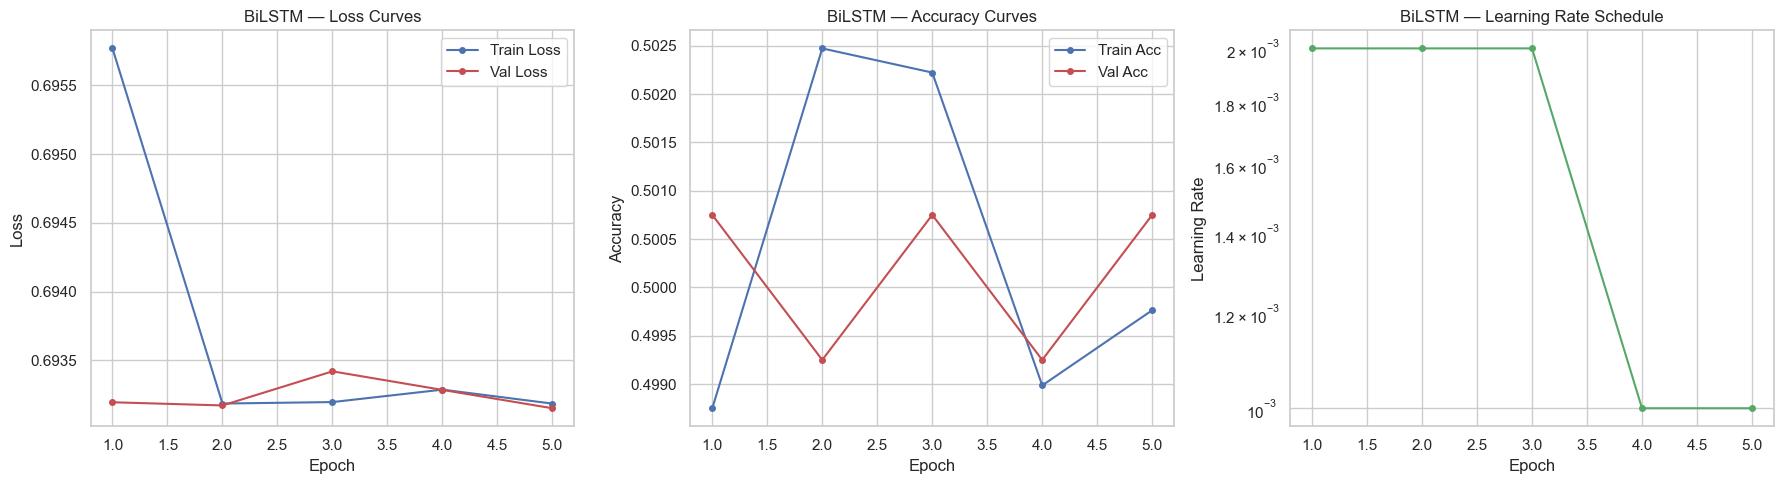

Saved: figures/lstm_training_curves.png


In [8]:
# Plot BiLSTM training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(lstm_history['train_loss']) + 1)

axes[0].plot(epochs_range, lstm_history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, lstm_history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('BiLSTM — Loss Curves')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, lstm_history['train_acc'], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_range, lstm_history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('BiLSTM — Accuracy Curves')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs_range, lstm_history['lr'], 'g-o', markersize=4)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('BiLSTM — Learning Rate Schedule')
axes[2].set_yscale('log'); axes[2].grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/lstm_training_curves.png')

### Overfitting Analysis

If the gap between training and validation loss widens, the model is memorising
noise.  Our defences:

1. **Early stopping** (patience=4) — halts training before the val loss climbs.
2. **Dropout (0.3)** — on embeddings and between FC layers, forces redundant representations.
3. **ReduceLROnPlateau** — shrinks LR when validation loss plateaus, enabling finer optimisation.
4. **Weight decay (L2 = 1e-4)** — penalises large weights via decoupled AdamW.
5. **Gradient clipping** — prevents destabilising parameter updates from long sequences.

---

## 3. Model B — DistilBERT Fine-tuning

### Architecture (not a black box)

```
Input text
       │
       ▼
┌──────────────────────────┐
│  HuggingFace WordPiece   │  Subword tokenizer (30,522 vocab)
│  Tokenizer               │  Adds [CLS] and [SEP], pads to max_length
└────────┬─────────────────┘
         ▼
┌──────────────────────────┐
│  DistilBERT Encoder      │  6 Transformer layers, 768-d hidden
│  (66M params, pretrained)│  Multi-head self-attention (12 heads)
│                          │  Feed-forward: 768 → 3072 → 768 (GELU)
└────────┬─────────────────┘
         ▼  [CLS] token representation
┌──────────────────────────┐
│  LayerNorm               │  Stabilises hidden state distribution
│  + Dropout(0.3)          │  Regularises the new classification head
└────────┬─────────────────┘
         ▼
┌──────────────────────────┐
│  Linear 768 → 2          │  Kaiming init, output logits
└──────────────────────────┘
```

### Why DistilBERT?

| Aspect | Detail |
|--------|--------|
| **Knowledge distillation** | Trained to mimic BERT-base; retains 97 % of language understanding at 60 % of the parameters |
| **Practical for 100k samples** | 66M parameters vs BERT's 110M; ~1.6× faster inference |
| **Differential learning rate** | Pretrained body at 0.1× the head LR — fine-tunes semantic layers gently |
| **Layer freezing** | Embedding + first 2 Transformer layers are frozen (syntactic knowledge transfers well) |
| **SubWord tokenization** | WordPiece handles unseen domain words by splitting into known sub-units |

### Transformer self-attention mechanism

Each attention head computes:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

where $Q$, $K$, $V$ are linear projections and $\sqrt{d_k}$ prevents dot products
from growing too large.  **Multi-head attention** runs this in parallel with
different projections, letting the model attend to different aspects simultaneously
(e.g., one head focuses on sentiment, another on pricing language).

In [14]:
# Load DistilBERT preprocessed data
bert_train_enc = torch.load(RESULTS_DIR / 'dl_bert_train.pt', weights_only=False)
bert_val_enc   = torch.load(RESULTS_DIR / 'dl_bert_val.pt',   weights_only=False)
bert_test_enc  = torch.load(RESULTS_DIR / 'dl_bert_test.pt',  weights_only=False)

bert_train_labels = np.load(RESULTS_DIR / 'dl_bert_y_train.npy')
bert_val_labels   = np.load(RESULTS_DIR / 'dl_bert_y_val.npy')

print(f'DistilBERT data loaded:')
print(f'  Train: {bert_train_enc["input_ids"].shape}  Val: {bert_val_enc["input_ids"].shape}')
print(f'  Test:  {bert_test_enc["input_ids"].shape}')

/Users/bhavanishanker/predictive-sales-analytics-engine/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DistilBERT data loaded:
  Train: torch.Size([2000, 128])  Val: torch.Size([500, 128])
  Test:  torch.Size([20000, 128])


In [15]:
# Build DistilBERT model
bert_cfg = TransformerConfig(
    model_name='distilbert-base-uncased',
    max_length=512,
    dropout=0.3,
    num_classes=2,
    freeze_layers=2,
)

bert_model = DistilBERTClassifier(bert_cfg)

total_params = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params
print(f'DistilBERT Classifier')
print(f'  Total parameters:     {total_params:>12,}')
print(f'  Trainable parameters: {trainable_params:>12,}')
print(f'  Frozen parameters:    {frozen_params:>12,}')
print(f'  Frozen: embedding + {bert_cfg.freeze_layers} Transformer layers')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6042.01it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT Classifier
  Total parameters:       66,365,954
  Trainable parameters:   28,354,562
  Frozen parameters:      38,011,392
  Frozen: embedding + 2 Transformer layers


In [16]:
BERT_BATCH       = 8   # keep small for training
BERT_EVAL_BATCH  = 64  # safe for inference on Mac (no gradient memory needed)

bert_train_ds = TransformerDataset(bert_train_enc, bert_train_labels)
bert_val_ds   = TransformerDataset(bert_val_enc,   bert_val_labels)
bert_test_ds  = TransformerDataset(bert_test_enc,  y_test)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BERT_BATCH,      shuffle=True,  num_workers=0)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=BERT_EVAL_BATCH, shuffle=False, num_workers=0)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=BERT_EVAL_BATCH, shuffle=False, num_workers=0)

print(f'DistilBERT DataLoaders:')
print(f'  Train: {len(bert_train_loader)} batches  Val: {len(bert_val_loader)} batches  Test: {len(bert_test_loader)} batches')

DistilBERT DataLoaders:
  Train: 250 batches  Val: 8 batches  Test: 313 batches


In [ ]:
# Train DistilBERT
bert_train_cfg = TrainingConfig(
    batch_size=BERT_BATCH,
    epochs=5,           # reduced from 10
    lr=2e-4,
    weight_decay=1e-2,
    patience=2,         # reduced from 3
    min_delta=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=1,
    grad_clip=1.0,
)

print('='*70)
print('Training DistilBERT (fine-tuning with differential LR)')
print(f'  Body LR: {bert_train_cfg.lr * 0.1:.1e}  |  Head LR: {bert_train_cfg.lr:.1e}')
print('='*70)
bert_history = train_transformer_model(
    bert_model, bert_train_loader, bert_val_loader,
    config=bert_train_cfg,
    save_dir=str(RESULTS_DIR),
)

Training DistilBERT (fine-tuning with differential LR)
  Body LR: 2.0e-05  |  Head LR: 2.0e-04
Epoch 01/5 | Train Loss: 0.6019 Acc: 0.6955 | Val Loss: 0.5234 Acc: 0.7300 | LR: 2.00e-04 | 1682.5s
Epoch 02/5 | Train Loss: 0.5003 Acc: 0.7700 | Val Loss: 0.5333 Acc: 0.7360 | LR: 2.00e-04 | 3164.8s


In [7]:
# Plot DistilBERT training curves
if 'bert_history' in locals():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range_b = range(1, len(bert_history['train_loss']) + 1)

    axes[0].plot(epochs_range_b, bert_history['train_loss'], 'b-o', label='Train Loss', markersize=4)
    axes[0].plot(epochs_range_b, bert_history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('DistilBERT — Loss Curves')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs_range_b, bert_history['train_acc'], 'b-o', label='Train Acc', markersize=4)
    axes[1].plot(epochs_range_b, bert_history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('DistilBERT — Accuracy Curves')
    axes[1].legend(); axes[1].grid(True)

    axes[2].plot(epochs_range_b, bert_history['lr'], 'g-o', markersize=4)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('DistilBERT — Learning Rate Schedule')
    axes[2].set_yscale('log'); axes[2].grid(True)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'distilbert_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: figures/distilbert_training_curves.png')
else:
    print('DistilBERT training history not found. Run the training cell first to generate the plot.')

DistilBERT training history not found. Run the training cell first to generate the plot.


## 4. Save Training Artifacts

Save training histories and DataLoader references so that `08_dl_evaluation.ipynb`
can evaluate without retraining.

In [8]:
# Save training histories
histories = {}
if 'lstm_history' in locals(): histories['BiLSTM'] = lstm_history
if 'bert_history' in locals(): histories['DistilBERT'] = bert_history

if histories:
    with open(METRICS_DIR / 'dl_training_history.json', 'w') as f:
        json.dump(histories, f, indent=2)

print('Training artifacts saved summary:')
if 'lstm_history' in locals(): print(f'  Best BiLSTM checkpoint:    results/model_lstm_best.pt')
if 'bert_history' in locals(): print(f'  Best DistilBERT checkpoint: results/model_distilbert_best.pt')
if histories: print(f'  Training histories:         metrics/dl_training_history.json')

Training artifacts saved summary:


In [9]:
summary = "## Training Summary\n\n"

if 'lstm_history' in locals():
    lstm_epochs = len(lstm_history['train_loss'])
    summary += f"### BiLSTM + Attention\n" \
               f"- Trained for **{lstm_epochs} epochs** (early stopping patience=4)\n" \
               f"- Final train loss: {lstm_history['train_loss'][-1]:.4f} | Val loss: {lstm_history['val_loss'][-1]:.4f}\n" \
               f"- Final train acc:  {lstm_history['train_acc'][-1]:.4f} | Val acc:  {lstm_history['val_acc'][-1]:.4f}\n" \
               f"- Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}\n\n"

if 'bert_history' in locals():
    bert_epochs = len(bert_history['train_loss'])
    summary += f"### DistilBERT (Fine-tuned)\n" \
               f"- Trained for **{bert_epochs} epochs** (early stopping patience=3)\n" \
               f"- Final train loss: {bert_history['train_loss'][-1]:.4f} | Val loss: {bert_history['val_loss'][-1]:.4f}\n" \
               f"- Final train acc:  {bert_history['train_acc'][-1]:.4f} | Val acc:  {bert_history['val_acc'][-1]:.4f}\n" \
               f"- Trainable parameters: {sum(p.numel() for p in bert_model.parameters() if p.requires_grad):,}\n\n"

summary += "**Next → `08_dl_evaluation.ipynb`**: Load checkpoints and evaluate on the test set."
display(Markdown(summary))

## Training Summary

**Next → `08_dl_evaluation.ipynb`**: Load checkpoints and evaluate on the test set.